# Analyse Helios Simulations
This notebook walks through the process of analysing helios simulations which follows 3 main steps:

    (1) Data Preparation
        This stage will setup the project directory, setup expected schemas for dataframes (both dask and pandas), and ultimately read in the helios data and prepare the required per ray information into a .parquet output.
        It will also setup the reference dataset for voxels for each voxel_size in the project (i.e. unique voxel_ids etc.).
    
    (2) Voxel-Ray Intersection
        With valid rays saved per leg of the scan, in the previous step, the goal now is to check ray intersections in all voxels. This will record important information, such as the entry/exit/hit coordinates of the ray which will later be used to gather metrics.
        The main reason these metrics are not gathered yet, is that this stage will remain separate per leg. That way, the metrics can be computed from different combinations of helios legs without re-computing voxel-ray intersections.

    (3) Compute Metrics
        Taking a given set of legs and voxel_sizes, the voxel_ray intersection files will be used to calculate metrics for each voxel, in this case resulting in all outputs from each investigated method.

# Step 1 - Setup Project
Set project paths here

In [1]:
import os

# Set up the project directory
project_dir = '/home/capheus/projects/51_tree_test/024_Trees'
helios_dir = os.path.join(project_dir, 'helios')
references_dir = os.path.join(project_dir, 'references')
results_dir = os.path.join(project_dir, 'results')
valid_rays_dir = os.path.join(project_dir, 'valid_rays')

if not os.path.exists(helios_dir) or not os.path.exists(references_dir):
    raise FileNotFoundError("The specified directories do not exist. Please check the paths.")

if not os.path.exists(valid_rays_dir):
    os.makedirs(valid_rays_dir, exist_ok=True)

if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

use_class = False
leaf_object_ids = [1]
wood_object_ids = [0]


## Step 1 - Data Preparation
This step focuses on converting helios simulation outputs, saving only valid rays into a more efficient .parquet file format.

It expects the following input and will add a new folder (valid_rays) to store all resulting .parquet files.

INPUT:
    project_dir/
    ├── reference/
    │   ├── "{project}_voxel_size_0.2.csv"
    │   ├── "{project}_voxel_size_0.5.csv"
    │   ...
    │   └── "{project}_voxel_size_{v}.csv"
    ├── helios/
    │   ├── "leg000_points.xyz"
    │   ├── "leg000_pulse.txt"
    │   ├── "leg000_fullwave.txt"
    │   ├── "leg001_points.xyz"
    │   ├── "leg001_pulse.txt"
    │   ├── "leg001_fullwave.txt"
    │   ├── ...
    │   ├── "leg{l}_points.xyz"
    │   ├── "leg{l}_pulse.txt"
    │   └── "leg{l}_fullwave.txt"

OUTPUT:
    └── valid_rays/
        ├── "leg_000_valid_rays.parquet"
        ├── "leg_001_valid_rays.parquet"
        ...
        └── "leg_{l}_valid_rays.parquet"

Processing dask delayed functions...
[########################################] | 100% Completed | 211.01 ms
Processing leg 0...
[########################################] | 100% Completed | 2.88 ss
Processing leg 1...
[########################################] | 100% Completed | 3.06 ss
Processing leg 2...
[########################################] | 100% Completed | 3.05 ss
Processing leg 3...
[########################################] | 100% Completed | 3.18 ss
Processing leg 4...
[########################################] | 100% Completed | 3.07 ss
Processing leg 5...
[########################################] | 100% Completed | 3.18 ss
Processing leg 6...
[########################################] | 100% Completed | 3.18 ss
Processing leg 7...
[########################################] | 100% Completed | 2.98 ss
Processing leg 8...
[########################################] | 100% Completed | 3.08 ss
Processing leg 9...
[########################################] | 100% Completed |

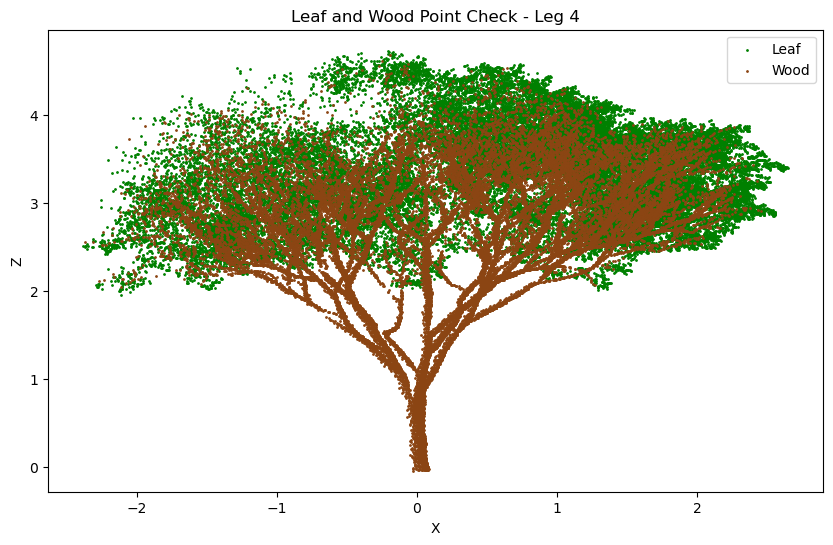

Saving leaf and wood point clouds...
Helios data preparation complete.


<Figure size 640x480 with 0 Axes>

In [5]:
from utils import prepare_helios_data

# Run the data preparation script
prepare_helios_data(
    input_dir=helios_dir, 
    output_dir=valid_rays_dir, 
    references_dir=references_dir, 
    leaf_object_ids=leaf_object_ids, 
    wood_object_ids=wood_object_ids, 
    use_class=use_class,
    debug=True
)

### Step 1.5 -  Compute Normals and Weights for Leaf Points

In [3]:
from utils import add_normals_weights_to_valid_rays

# Calculate normals and weights by loading valid rays
add_normals_weights_to_valid_rays(
    valid_rays_dir, 
    debug=True,
    knn=6
)

Adding normals and weights to 12 files...
[########################################] | 100% Completed | 63.33 s
Initialising voxels


Processing voxels: 100%|██████████| 1/1 [00:01<00:00,  1.59s/it]


Saving results...
Debugging enabled:
          leg_id   ray_id  origin_x  origin_y  origin_z  direction_x  \
21641780       0  1402773      10.0       0.0    1.6386      -0.9557   
21641829       0  1402774      10.0       0.0    1.6386      -0.9555   
21642717       0  1403710      10.0       0.0    1.6386      -0.9559   
21642742       0  1403711      10.0       0.0    1.6386      -0.9557   
21645756       0  1411197      10.0       0.0    1.6386      -0.9596   

          direction_y  direction_z  point_x  point_y  point_z  echo_intensity  \
21641780       0.2587       0.1403   0.4176   2.5942   3.0452    1.250852e+07   
21641829       0.2587       0.1419   0.4634   2.5818   3.0553    8.500677e+06   
21642717       0.2579       0.1403   0.4140   2.5862   3.0454    1.249774e+07   
21642742       0.2578       0.1419   0.4620   2.5732   3.0552    9.360689e+06   
21645756       0.2517       0.1253   0.4312   2.5100   2.8884    1.611489e+07   

          return_number  number_of_returns 

/home/capheus/PlantDensityAnalysis/utils.py:3658: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_df.apply(save_group, include_groups=True)


## Step 2 - Voxel Ray Intersections
This code uses the valid rays from before, alongside the reference datasets in order to create a supporting parquet in the valid rays folder using the voxel_size_{voxel_size}_leg_{leg}_intersections.parquet format.

In [2]:
from utils import voxel_ray_intersections

# Run intersections
voxel_ray_intersections(
    valid_rays_dir=valid_rays_dir, 
    references_dir=references_dir,
    debug=False
)

Initialising leg 4 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 3 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 2 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 0 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 9 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 10 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 11 - 12 partitions, 6746271 rays, 4734 voxels, 613297 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 7 - 12 partitions, 6746624 rays, 4734 voxels, 613329 rays/partition, 57 voxels/chunk, 83 chunks
Initialising leg 6 - 12 partitions, 6746368 rays, 4734 voxels, 613306 rays/partition, 57 voxel

KeyboardInterrupt: 

## Step 3 - Compute Metrics
Using the leg_{leg_id}_voxel_size_{voxel_size}_intersections.parquet files (which feature a standardised structure of columns from various inputs), compute the desired metrics and save outputs.

### Step 3.1 - Multi-return
Use the get_voxel_metrics_multireturn function to handle mutli return projects.

In [ ]:
import os
import glob
import utils
import pandas as pd
from utils import calculate_lambda_1, get_voxel_metrics, get_voxel_metrics_old

# Select the desired legs and voxel_sizes to include in the analysis
# Use the shortcut string 'all' to include all 
legs = 'all' # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] 
voxel_sizes = 'all' # 'all' # [0.2, 0.5, 1.0, 2.0]

# Set the average leaf area
average_leaf_area = 0.0024149995507188344  # in m^2, adjust as needed

# Get the list of all voxel sizes
intersection_files = []
if legs == 'all' and voxel_sizes == 'all':
    intersection_files = glob.glob(os.path.join(valid_rays_dir, '*_intersections.parquet'))
elif legs == 'all' and isinstance(voxel_sizes, list):
    for voxel_size in voxel_sizes:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_*_voxel_{voxel_size}_intersections.parquet'))
elif isinstance(legs, list) and voxel_sizes == 'all':
    for leg in legs:
        intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_*_intersections.parquet'))
else:
    for leg in legs:
        for voxel_size in voxel_sizes:
            intersection_files += glob.glob(os.path.join(valid_rays_dir, f'leg_{leg}_voxel_{voxel_size}_intersections.parquet'))

# Check if any intersection files were found
if intersection_files == []:
    print("No intersection files found. Please check the input parameters.")

# Split intersection files into separate lists for each voxel_size
voxel_size_files = {}
for file in intersection_files:
    # Extract the voxel size from the filename
    parts = file.split('_')
    voxel_size = float(parts[parts.index('voxel') + 1])
    
    # Add the file to the corresponding voxel size list
    if voxel_size not in voxel_size_files:
        voxel_size_files[voxel_size] = []
    voxel_size_files[voxel_size].append(file)

# Extract voxel information for each voxel size
for voxel_size, files in voxel_size_files.items():
    # Create a list of all legs in files
    legs = []
    for file in files:
        leg = os.path.basename(file)
        parts = leg.split('_')
        leg = int(parts[parts.index('leg') + 1])
        legs.append(leg)

    # Calculate the lambda_1 for average leaf area
    lambda_1 = calculate_lambda_1(voxel_size=voxel_size, average_leaf_area=average_leaf_area)
    print(f"Voxel size: {voxel_size}, Lambda_1: {lambda_1}")

    # Calculate per voxel information from all files
    voxel_metrics_df = get_voxel_metrics(
        intersections_files=files, 
        lambda_1=lambda_1,
        is_multireturn=False
    )

    # Retrieve the reference file
    reference_file = glob.glob(os.path.join(references_dir, f'*voxel_size_{voxel_size}*'))[0]
    df_ref = pd.read_csv(reference_file)

    # CI_leaf_Corr, CI_lw_Corr
    # Ensure only numeric columns are included in the mean operation
    df_ref = df_ref.groupby('voxel_id').mean(numeric_only=True).reset_index()
    df_ref = df_ref.add_suffix('_ref')


    df_ref.rename(columns={
        'voxel_id_ref': 'voxel_id',
        'LAD_ref_ref': 'LAD_ref', 
        'PAD_ref_ref': 'PAD_ref'
        }, inplace=True)

    # Merge to maintain voxel_id matching
    voxel_metrics_df = voxel_metrics_df.merge(df_ref, on='voxel_id', how='left')
    voxel_metrics_df.drop(columns=[
        "voxel_cx_ref",
        "voxel_cy_ref",
        "voxel_cz_ref"
    ])

    ### Add LAD calculations here if desired
    """Example, LAD_BL_TLS

    # Retrieve required variables
    I_leaf = voxel_metrics_df['I_leaf'].values
    mean_path_length = voxel_metrics_df['mean_path_length'].values  
    G_leaf = voxel_metrics_df['G_leaf'].values
    CI_leaf_ref = voxel_metrics_df['CI_leaf_corr_ref'].values

    LAD_BL_TLS = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length)
    LAD_BL_TLS_G = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf)
    LAD_BL_TLS_CI_ref = utils.BL_pimont_2018(I=I_leaf, mean_path_length=mean_path_length, G=G_leaf, CI=CI_leaf_ref)
    """

    # Save outputs to csv
    project_name = os.path.basename(os.path.normpath(project_dir))
    legs.sort()
    leg_string = "_".join(map(str, legs))
    output_file = os.path.join(results_dir, f"{project_name}_leg_{leg_string}_voxel_size_{voxel_size}.csv")
    if os.path.exists(output_file):
        os.remove(output_file)
    voxel_metrics_df.to_csv(output_file)

Voxel size: 1.0, Lambda_1: 0.0024149995507188344
[##################                      ] | 47% Completed | 811.18 ms


KeyboardInterrupt: 

# Step 4 - Final Validation
Check helios raw outputs vs results

In [ ]:
import os
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np

helios_files = glob.glob(os.path.join(helios_dir, "*.xyz"))
# Load all xyz files into a single 3D point cloud
leaf_points = []
wood_points = []
invalid_points = []
for xyz_file in helios_files:
    points = pd.read_csv(xyz_file, delimiter=' ', header=None, names=['point_x', 'point_y', 'point_z', 'echo_intensity', 'echo_width', 'return_number', 'number_of_returns', 'ray_id', 'hit_object_id', 'class', 'gps_time'])
    # Split points on hit_object_id or class 
    object_key = 'hit_object_id' if not use_class else 'class'
    leaf_mask = points[object_key].isin(leaf_object_ids)
    wood_mask = points[object_key].isin(wood_object_ids)
    # Combine leaf and wood object ids for invalid mask
    valid_object_ids = leaf_object_ids + wood_object_ids
    invalid_mask = ~points[object_key].isin(valid_object_ids)

    leaf_points.append(points[['point_x', 'point_y', 'point_z']][leaf_mask])
    wood_points.append(points[['point_x', 'point_y', 'point_z']][wood_mask])
    invalid_points.append(points[['point_x', 'point_y', 'point_z']][invalid_mask])

leaf_points = np.vstack(leaf_points) if leaf_points else np.empty((0, 3))
wood_points = np.vstack(wood_points) if wood_points else np.empty((0, 3))
invalid_points = np.vstack(invalid_points) if invalid_points else np.empty((0, 3))

# Count points that are practically over the top of one another (to 1e-6)
def count_duplicate_points(points, tol=1e-6):
    if points.shape[0] == 0:
        return 0
    rounded = np.round(points.astype(np.float32) / tol) * tol
    _, counts = np.unique(rounded, axis=0, return_counts=True)
    return np.sum(counts > 1)

num_leaf_duplicates = count_duplicate_points(leaf_points)
num_wood_duplicates = count_duplicate_points(wood_points)
num_invalid_duplicates = count_duplicate_points(invalid_points)

print(f"Leaf points with duplicates (tol=1e-6): {num_leaf_duplicates}")
print(f"Wood points with duplicates (tol=1e-6): {num_wood_duplicates}")
print(f"Invalid points with duplicates (tol=1e-6): {num_invalid_duplicates}")

results_files = glob.glob(os.path.join(results_dir, "*.csv"))

for file in results_files:
    results_df = pd.read_csv(file)
    voxel_size = results_df['voxel_size_ref'].iloc[0]
    voxel_centres = results_df[['voxel_cx', 'voxel_cy', 'voxel_cz']].values
    num_hits = results_df['num_hits'].values
    num_leaf_hits = results_df['num_leaf_hits'].values

    # Validation: check if sum of num_hits matches total number of leaf and wood points
    total_voxel_hits = np.sum(num_hits)
    total_points = leaf_points.shape[0] + wood_points.shape[0]
    if total_voxel_hits != total_points:
        print(f"Total num_hits ({total_voxel_hits}) does not match total leaf+wood points ({total_points}) in {file}")
        
        intersection_files = glob.glob(os.path.join(valid_rays_dir, f'*voxel_{voxel_size}_intersections.parquet'))

        leaf_points_to_save = []
        wood_points_to_save = []
        for intersection_file in intersection_files:
            df = pd.read_parquet(intersection_file)
            # Use object_key to split points
            hit_mask = df['hit_type'] == 2
            leaf_mask = df['is_leaf'] == True
            leaf_cloud = df[leaf_mask & hit_mask][['point_x', 'point_y', 'point_z']].values
            wood_cloud = df[~leaf_mask & hit_mask][['point_x', 'point_y', 'point_z']].values

            # Save to results folder
            base_name = os.path.splitext(os.path.basename(intersection_file))[0]
            leaf_points_to_save.append(leaf_cloud)
            wood_points_to_save.append(wood_cloud)

        # Save all collected points to disk
        if leaf_points_to_save:
            leaf_points_to_save = np.vstack(leaf_points_to_save)
            if len(leaf_points_to_save) == leaf_points.shape[0]:
                print(f"All leaf points are already in {file}, no new points to save.")  
            else:
                print(f"Missing {leaf_points.shape[0] - len(leaf_points_to_save)} leaf points in {file}.")
                pcd_points = []
                # Find points in leaf_points that are missing from leaf_points_to_save
                missing_leaf_points = []
                for point in leaf_points:
                    if not np.any(np.all(np.isclose(leaf_points_to_save.astype(np.float32), point.astype(np.float32), atol=1e-6), axis=1)):
                        missing_leaf_points.append(point)
                if missing_leaf_points:
                    print(f"Number of leaf points missing from leaf_points_to_save: {len(missing_leaf_points)}")
                    leaf_out = os.path.join(results_dir, f"{voxel_size}_missing_leaf_points.xyz")
                    leaf_xyz = np.vstack(missing_leaf_points)
                    np.savetxt(leaf_out, leaf_xyz, fmt='%.8f')
                else:
                    print("All leaf_points are present in leaf_points_to_save (within tolerance).")

            
        if wood_points_to_save:
            wood_points_to_save = np.vstack(wood_points_to_save)
            if len(wood_points_to_save) == wood_points.shape[0]:
                print(f"All wood points are already in the {file}, no new points to save.")
            else:
                print(f"Missing {wood_points.shape[0] - len(wood_points_to_save)} wood points in {file}.")
                missing_wood_points = []
                for point in wood_points:
                    if not np.any(np.all(np.isclose(wood_points_to_save.astype(np.float32), point.astype(np.float32), atol=1e-6), axis=1)):
                        missing_wood_points.append(point)
                if missing_wood_points:
                    print(f"Number of wood points missing from wood_points_to_save: {len(missing_wood_points)}")
                    wood_out = os.path.join(results_dir, f"{voxel_size}_missing_wood_points.xyz")
                    wood_xyz = np.vstack(missing_wood_points)
                    np.savetxt(wood_out, wood_xyz, fmt='%.8f')

        valid_rays_files = glob.glob(os.path.join(valid_rays_dir, f'*valid_rays.parquet'))
        valid_leaf_points = []
        valid_wood_points = []
        for valid_rays_file in valid_rays_files:
            valid_rays = pd.read_parquet(valid_rays_file)
            
            hit_mask = ~valid_rays['point_x'].isna()
            leaf_mask = valid_rays['is_leaf'] == True
            # Collect new points in temporary lists
            new_leaf_points = valid_rays[['point_x', 'point_y', 'point_z']][hit_mask & leaf_mask].values
            new_wood_points = valid_rays[['point_x', 'point_y', 'point_z']][hit_mask & ~leaf_mask].values

            valid_leaf_points.append(new_leaf_points)
            valid_wood_points.append(new_wood_points)
        
        valid_leaf_points = np.vstack(valid_leaf_points) if valid_leaf_points else np.empty((0, 3))
        valid_wood_points = np.vstack(valid_wood_points) if valid_wood_points else np.empty((0, 3))

        if len(valid_leaf_points) != leaf_points.shape[0]:
            print(f"Number of valid leaf points ({len(valid_leaf_points)}) does not match total leaf points ({leaf_points.shape[0]}) in {file}")
            missing_valid_leaf_points = []
            for point in leaf_points:
                if not any(np.all(np.isclose(valid_leaf_points.astype(np.float32), point.astype(np.float32), atol=1e-6), axis=1)):
                    missing_valid_leaf_points.append(point)
            if missing_valid_leaf_points:
                print(f"Number of leaf points missing from valid_leaf_points: {len(missing_valid_leaf_points)}")
                valid_leaf_out = os.path.join(results_dir, f"{voxel_size}_missing_valid_leaf_points.xyz")
                np.savetxt(valid_leaf_out, np.vstack(missing_valid_leaf_points), fmt='%.8f')
            else:
                print("All leaf_points are present in valid_leaf_points (within tolerance).")
        if len(valid_wood_points) != wood_points.shape[0]:
            print(f"Number of valid wood points ({len(valid_wood_points)}) does not match total wood points ({wood_points.shape[0]}) in {file}")
            missing_valid_wood_points = []
            for point in wood_points:
                if not any(np.all(np.isclose(valid_wood_points.astype(np.float32), point.astype(np.float32), atol=1e-6), axis=1)):
                    missing_valid_wood_points.append(point)
            if missing_valid_wood_points:
                print(f"Number of wood points missing from valid_wood_points: {len(missing_valid_wood_points)}")
                valid_wood_out = os.path.join(results_dir, f"{voxel_size}_missing_valid_wood_points.xyz")
                np.savetxt(valid_wood_out, np.vstack(missing_valid_wood_points), fmt='%.8f')
            else:
                print("All wood_points are present in valid_wood_points (within tolerance).")

    total_voxel_leaf_hits = np.sum(num_leaf_hits)
    if total_voxel_leaf_hits != leaf_points.shape[0]:
        print(f"Total num_leaf_hits ({total_voxel_leaf_hits}) does not match total leaf points ({leaf_points.shape[0]}) in {file}")

    for i, vc, nh, nlh in tqdm(list(zip(range(len(voxel_centres)), voxel_centres, num_hits, num_leaf_hits)), desc=f"Validating voxels for {file}"):
        # Find the number of total hits, wood hits, and leaf hits in leaf_points and wood_points
        # Calculate voxel bounds
        half_size = voxel_size / 2.0
        min_bound = vc - half_size - 1e-9
        max_bound = vc + half_size + 1e-9

        # Count leaf points inside voxel
        leaf_hits = np.sum(
            np.all((leaf_points > min_bound) & (leaf_points < max_bound), axis=1)
        )
        # Count wood points inside voxel
        wood_hits = np.sum(
            np.all((wood_points > min_bound) & (wood_points < max_bound), axis=1)
        )
        # Total hits
        total_hits = leaf_hits + wood_hits
        # Invalid hits
        invalid_hits = np.sum(
            np.all((invalid_points > min_bound) & (invalid_points < max_bound), axis=1)
        )

        if total_hits != nh:
            print(f"num_hits discrepancy in {file}, voxel {i}: {total_hits} != {nh}")
        if leaf_hits != nlh:
            print(f"num_leaf_hits discrepancy in {file}, voxel {i}: {leaf_hits} != {nlh}")
        if invalid_hits > 0:
            print(f"num_invalid_hits in {file}, voxel {i}: {invalid_hits} > 0")

        if total_hits == nh and leaf_hits == nlh and invalid_hits == 0:
            print(f"Voxel {i} in file {file} is valid: {total_hits} hits, {leaf_hits} leaf hits, {wood_hits} wood hits, {invalid_hits} invalid hits.")


Leaf points with duplicates (tol=1e-6): 0
Wood points with duplicates (tol=1e-6): 0
Invalid points with duplicates (tol=1e-6): 0


KeyError: 'voxel_size_ref'